# Initialization of libraries to be used as well as loading of the data. <br>

In [258]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sb
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
plt.style.use('seaborn-v0_8-whitegrid')
sb.set_palette("husl")

In [259]:
df = pd.read_csv("data/beatmaps.csv")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
print(df.columns.to_list())
df = df.drop(columns=['file_md5', 'tags', 'download_unavailable', 'audio_unavailable'])

['beatmapset_id', 'beatmap_id', 'approved', 'total_length', 'hit_length', 'version', 'file_md5', 'diff_size', 'diff_overall', 'diff_approach', 'diff_drain', 'mode', 'count_normal', 'count_slider', 'count_spinner', 'submit_date', 'approved_date', 'last_update', 'artist', 'title', 'creator', 'creator_id', 'bpm', 'source', 'tags', 'genre_id', 'language_id', 'favourite_count', 'rating', 'download_unavailable', 'audio_unavailable', 'playcount', 'passcount', 'max_combo', 'diff_aim', 'diff_speed', 'difficultyrating']


# Adjust the data by removing rows that are not relevant to this project. <br>
> Remove all rows where mode is not 0 (the standard osu game mode). <br>
> Remove all rows that are either pending (0), WIP (-1), or graveyard (-2) <br>
> Remove all rows where the total song time is less than 40 seconds or greater than 2 standard deviations from the mean. <br>
> Remove all rows where the Drain Ratio (Hit length / Total Length) is less than 0.6, This means that the map is less than 60% game time and a large part is empty audio (intros, outros, massive breaks) and is a good indicator of > a low-quality beatmap. <br>
>Remove maps where there are impossible statistics / data collection inaccuracy (bpm >= 500, difficultyrating >= 11) <br>
Any map that falls into one of these categories will be considered as these maps are generally incomplete or of low quality (meme maps, endurance maps, practice maps, etc).

In [260]:
# Drop the rows using their indices, modifying the DataFrame in-place
df.drop(df[df['mode'] != 0].index, inplace= True)
df.drop(df[df['approved'].isin([0, -1, -2])].index, inplace=True)
#calculate bounds
total_length_mean_val = df['total_length'].mean()
total_length_std_val = df['total_length'].std()
hit_length_mean_val = df['hit_length'].mean()
hit_length_std_val = df['hit_length'].std()
min_total_length = 40
max_total_length = total_length_mean_val + 2 * total_length_std_val
max_hit_length = hit_length_mean_val + 2 * hit_length_std_val
# Overwrite df with only the rows that meet the length criteria
df = df[
    (df['total_length'] >= min_total_length) & 
    (df['total_length'] <= max_total_length) &
    (df['hit_length'] >= min_total_length) &
    (df['hit_length'] <= max_hit_length)
]

# Calculate drain ratio, keep the high-quality maps, and drop the temporary column
df['drain_ratio'] = df['hit_length'] / df['total_length']
df = df[df['drain_ratio'] >= 0.60]
df = df.drop(columns=['drain_ratio'])

#Remove impossible beatmaps
df.drop(df[(df['bpm'] >= 500) | (df['bpm'] == 0)].index, inplace=True)
df.drop(df[df['difficultyrating'] >= 11].index, inplace= True)

# Summary statistics for the key numerical variables involved in our analysis.

In [261]:
df[['total_length', 'bpm', 'difficultyrating', 'count_normal', 'count_slider', 'count_spinner', 'playcount', 'favourite_count']].describe().round(2)

,total_length,bpm,difficultyrating,count_normal,count_slider,count_spinner,playcount,favourite_count
count,61686.00,61686.00,61686.00,61686.00,61686.00,61686.00,61686.00,61686.00
mean,139.65,155.29,3.26,181.01,139.91,2.23,152645.31,278.73
std,59.34,37.13,1.40,156.71,95.58,2.62,413711.37,538.04
min,40.00,15.00,0.43,0.00,0.00,0.00,0.00,0.00
25%,89.00,131.00,2.05,70.00,73.00,1.00,24129.50,61.00
50%,118.00,160.00,3.12,135.00,117.00,2.00,56897.00,131.00
75%,189.00,180.00,4.25,242.00,177.00,3.00,142382.50,285.00
max,299.00,468.75,10.48,1955.00,1106.00,212.00,25960995.00,15419.00


# Exploratory Data Analysis (EDA)

## Distribution of Playcount <br>
Typically playcounts follow an exponential distribution, most maps have a low playcount, while a few "mega-hits" garner millions of plays. By applying a logarithmic transformation, we can better visualize the spread of the data.

Text(0, 0.5, 'Frequency')

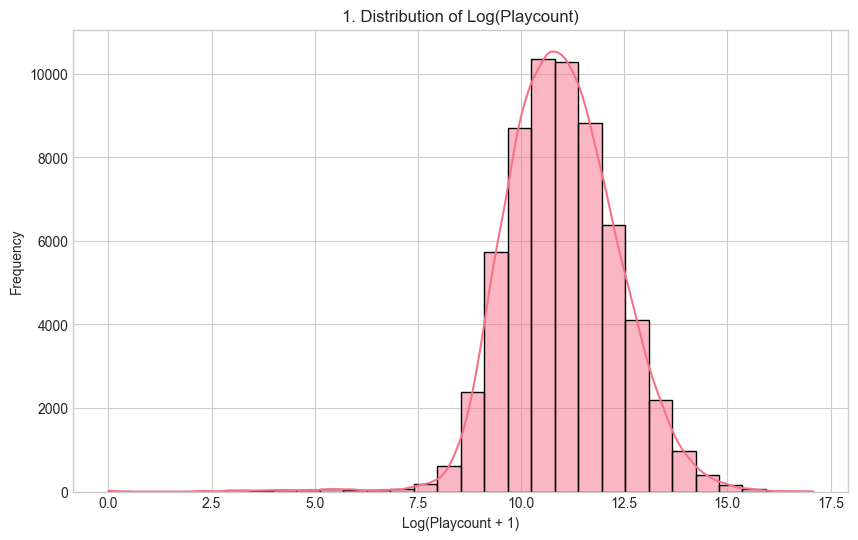

In [262]:
# 1. Distribution of Log(Playcount)
plt.figure(figsize=(10, 6))
sb.histplot(np.log1p(df['playcount']), bins=30, kde=True)
plt.title('1. Distribution of Log(Playcount)')
plt.xlabel('Log(Playcount + 1)')
plt.ylabel('Frequency')

## BPM Distribution: Popular vs Normal Maps
We segmented the top 10% most played maps and compared their BPM distribution to the rest of the dataset. There is a clear difference between the BPM of the top 10% of songs and the rest. Lower BPM maps, generally in the 75-150 range, are significantly less represented in the top 10% of maps compared to higher BPM maps. There is a clear spike around the 175 BPM range where a large majority of maps of maps in this range are in the top 10% of playcount. This indicates that players prefer songs with a higher bpm and that it directly contributes to the popularity of a map.

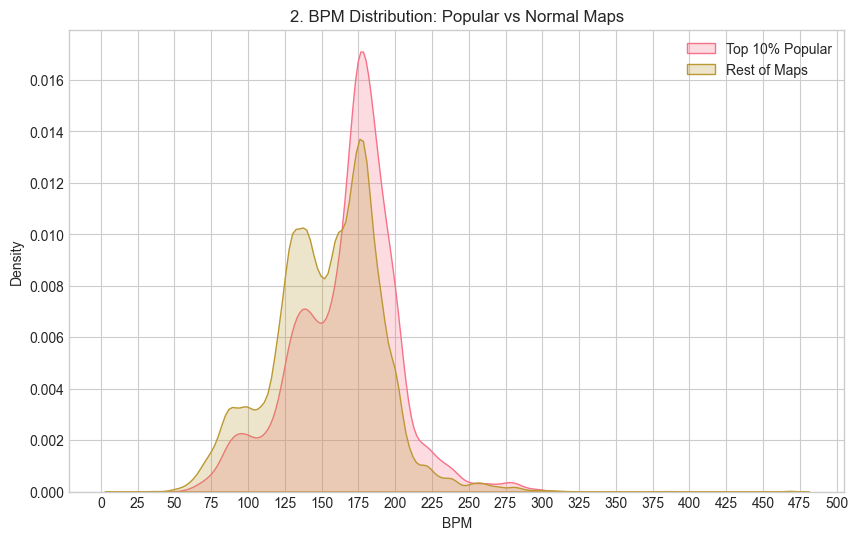

In [263]:
# Calculate Top 10%
top_10 = df[df['playcount'] > df['playcount'].quantile(0.9)]
rest = df[df['playcount'] <= df['playcount'].quantile(0.9)]

plt.figure(figsize=(10, 6))
sb.kdeplot(top_10['bpm'], label='Top 10% Popular', fill=True)
sb.kdeplot(rest['bpm'], label='Rest of Maps', fill=True)
plt.title('2. BPM Distribution: Popular vs Normal Maps')
plt.xlabel('BPM')
plt.ylabel('Density')
plt.gca().xaxis.set_major_locator(MultipleLocator(25))  #set x axsis ticker to a multiple of 25
plt.legend()

## Total Length Distrubition: Popular vs. Normal Maps <br>
Similar to BPM, this looks at song length. Most popular beatmaps often fall into the "TV Size" category (roughly 90 seconds, around the same time as a typical TV anime opening) because they are quick to retry and farm for performance points (PP). There is also a spike in the top 10% of maps around the 180 second mark and I can assume this is the average length of "standard" rhythm game songs (EDM, KPOP, ETC).

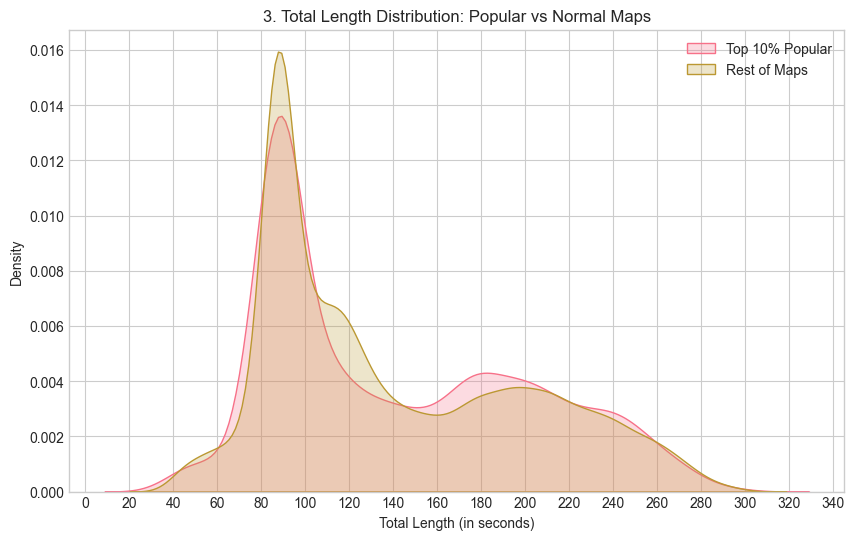

In [264]:
plt.figure(figsize=(10, 6))
sb.kdeplot(top_10['total_length'], label='Top 10% Popular', fill=True)
sb.kdeplot(rest['total_length'], label='Rest of Maps', fill=True)
plt.title('3. Total Length Distribution: Popular vs Normal Maps')
plt.xlabel('Total Length (in seconds)')
plt.ylabel('Density')
plt.gca().xaxis.set_major_locator(MultipleLocator(20))
plt.legend()

## Difficulty Rating vs. Playcount <br>
This scatterplot allows us to see the "sweet spot" for difficulty. Often, maps that are too easy or too overwhelmingly difficult have lower playcounts, while those in the mid-to-high difficulty range (e.g., 4 to 6 stars) attract the largest player base because they are challenging but accessible.

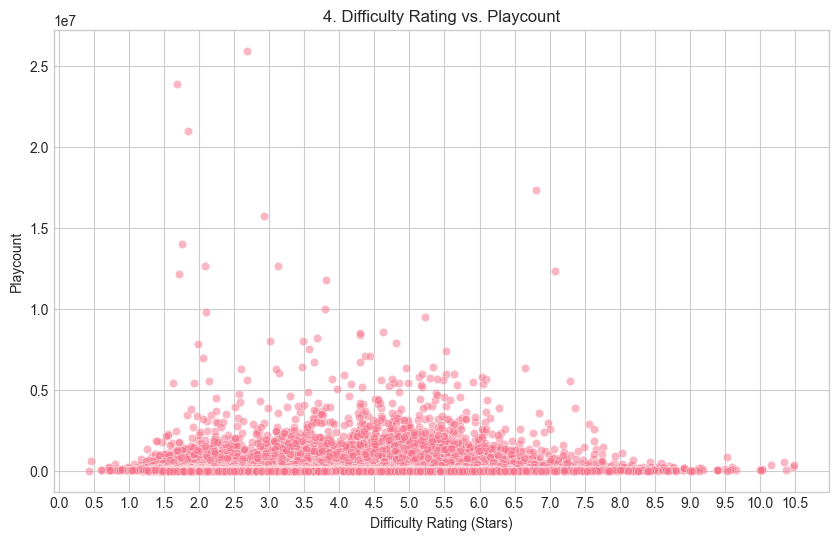

In [265]:
plt.figure(figsize=(10, 6))
sb.scatterplot(x='difficultyrating', y='playcount', alpha=0.5, data=df)
plt.title('4. Difficulty Rating vs. Playcount')
plt.xlabel('Difficulty Rating (Stars)')
plt.ylabel('Playcount')
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))


## Replayability vs. Appreciation (High Replay vs High Appreciation) <br>
By plotting the Replay Ratio (playcount divided by passcount) against the favourite_count, we can clearly identify distinct groups. The color represents the difficulty rating. Maps in the bottom-right have players retrying them endlessly (high replayability, often very difficult maps), while maps in the top-left are heavily favorited but not necessarily spammed (high appreciation, perhaps visually stunning or musically engaging maps)

Text(0, 0.5, 'Log(Favourite Count) [Appreciation]')

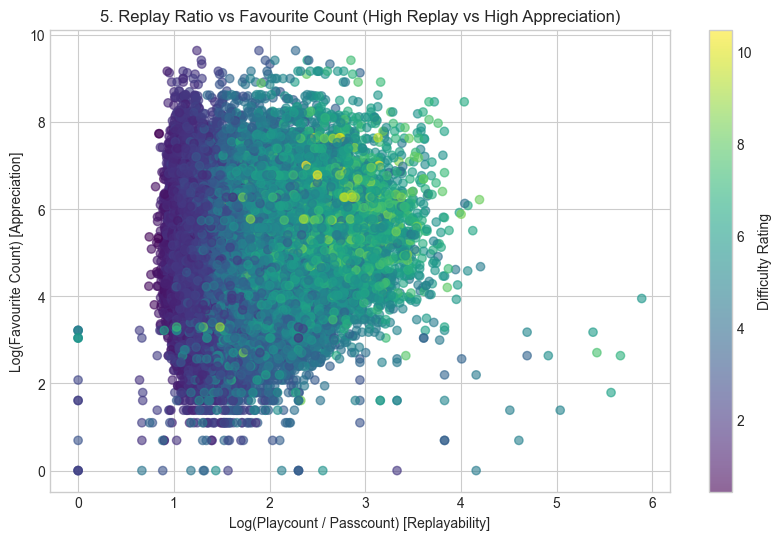

In [266]:
df['replay_ratio'] = df['playcount'] / (df['passcount'] + 1)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(np.log1p(df['replay_ratio']), np.log1p(df['favourite_count']), c=df['difficultyrating'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Difficulty Rating')
plt.title('5. Replay Ratio vs Favourite Count (High Replay vs High Appreciation)')
plt.xlabel('Log(Playcount / Passcount) [Replayability]')
plt.ylabel('Log(Favourite Count) [Appreciation]')

## Correlation Heatmap of Key Features <br>
This heatmap reveals how different numerical features interact. For example, max_combo and total_length are highly correlated. In relation to discovery question A, there is a clear correlation between playcount and difficulty rating. This shows that the more difficult a map is, generally it receives more plays than easier maps. Another example is the interesting correlation between a songs rating and its max combo, hinting that songs with a higher max combo generally receive a better rating than maps with a lower max combo.

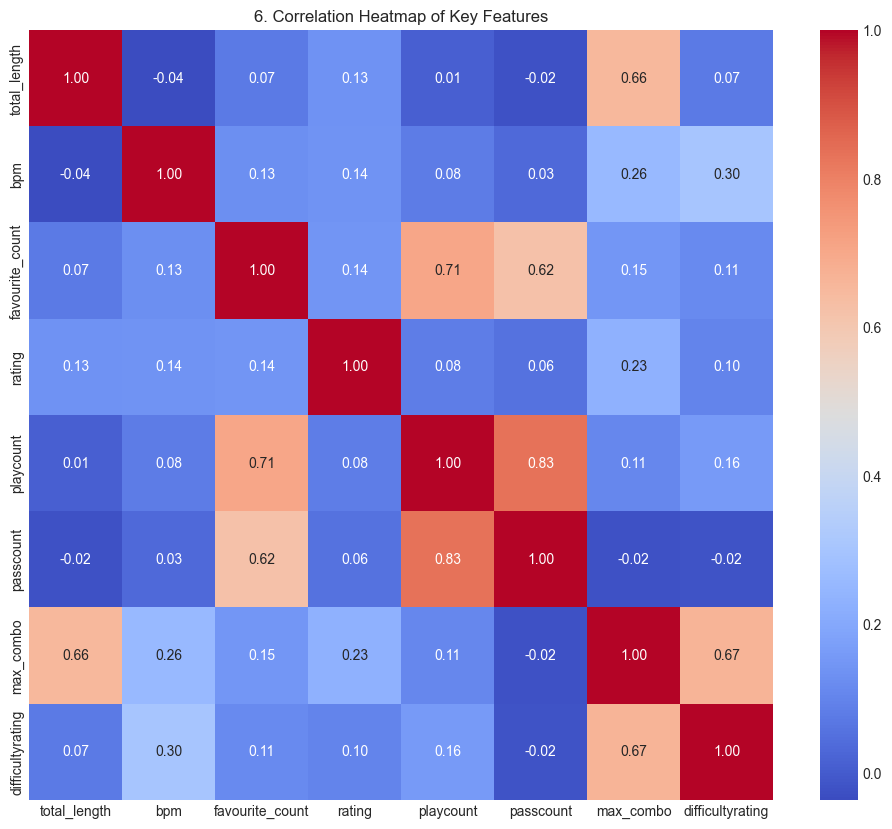

In [267]:
plt.figure(figsize=(12, 10))
cols = ['total_length', 'bpm', 'favourite_count', 'rating', 'playcount', 'passcount', 'max_combo', 'difficultyrating']
sb.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('6. Correlation Heatmap of Key Features')
plt.show()

# First Mining Technique: K-Means

## Preparing The Data
The most important metrics: replay ratio (playcount / passcount), favorite count, difficulty rating, bpm, and total length are set as features to be used in the K-Means scan. This first requires that the highly skewed variables (replay ratio and favorite count) are transformed using log(x+1) to prevent them from overpowering the other features.

In [268]:
df['replay_ratio'] = df['playcount'] / (df['passcount'] + 1)
features = ['replay_ratio', 'favourite_count', 'difficultyrating', 'bpm', 'total_length']
X = df[features].copy()
# Log transform the highly skewed variables
X['replay_ratio'] = np.log1p(X['replay_ratio'])
X['favourite_count'] = np.log1p(X['favourite_count'])
# Scale features so K-Means treats them equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Determining The Optimal Number of Clusters (k)
The optimal number of clusters was found to be only 2 by the Silhouette score. However this does not provide enough distinct groups and notably fails to capture differences the practical meaning between the groups.

In [ ]:
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow and Silhouette side-by-side
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(K_range, wcss, marker='o', linestyle='--')
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('WCSS')

ax[1].plot(K_range, silhouette_scores, marker='s', color='orange')
ax[1].set_title('Silhouette Scores')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Score')
plt.show()

## Using K as the optimal value.
As seen in the elbow method graph, at k=4 the WCSS value begins to slow it's decent and as such 4 was chosen as the optimal value.

Optimal clusters found: 4


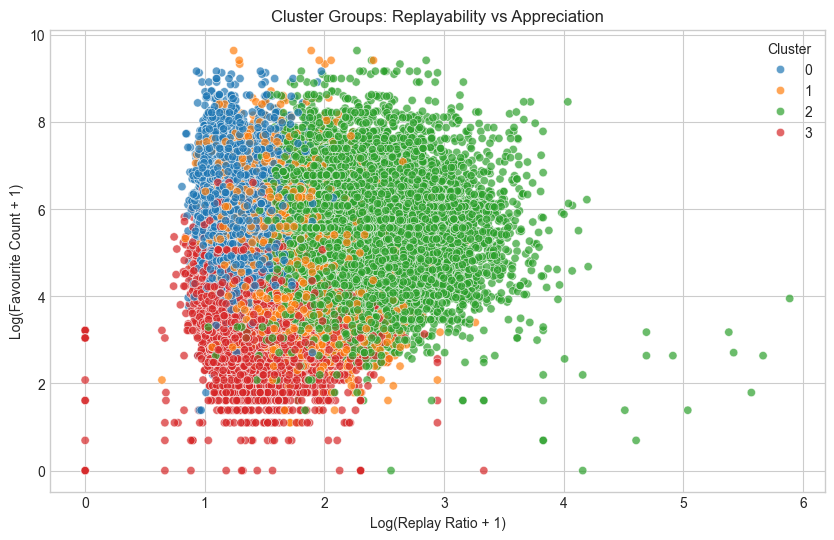

         replay_ratio  favourite_count  difficultyrating    bpm  total_length  \
cluster                                                                         
0                1.27             5.50              2.42 173.89        108.09   
1                1.60             4.93              2.82 138.69        218.99   
2                2.25             5.36              5.04 176.47        139.37   
3                1.40             3.91              2.58 130.42        106.62   

         count  
cluster         
0        14954  
1        13021  
2        16857  
3        16854  


In [ ]:
optimal_k = 4
print(f"Optimal clusters found: {optimal_k}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)
X['cluster'] = df['cluster']

# 4. Visualize the distinct popularity groups
plt.figure(figsize=(10, 6))
sb.scatterplot(x=X['replay_ratio'], y=X['favourite_count'], hue=X['cluster'], palette='tab10', alpha=0.7)
plt.title(f'Cluster Groups: Replayability vs Appreciation')
plt.xlabel('Log(Replay Ratio + 1)')
plt.ylabel('Log(Favourite Count + 1)')
plt.legend(title='Cluster')
plt.show()

# 5. Print the profiles of each cluster
cluster_profiles = X.groupby('cluster').mean()
cluster_profiles['count'] = X['cluster'].value_counts()
print(cluster_profiles.round(2))

## Connections to The Discovery Questions <br>
### Question 1: What map and song characteristics are most commonly shared among the most popular beatmaps? <br?>
By clustering, we can see that "popular" maps (high favorite and decent plays) do not all look the same. Cluster 2 reveals a highly popular segment driven by high BPM (~180+) and a high difficulty (~5). In contrast cluster 0 achieves popularity through shorter, easier gameplay (primarily targeting newer players). <br>
### Question 2: Are there distinct groups of songs that achieve popularity in different ways (high replay vs high appreciation)?
Cluster 2 (The Grind), perfectly defines the high replay category. The replay ratio (2.25) is massively higher than any other cluster. These maps have high difficulty, but they still achieve lots of plays from players constantly failing and retrying them, inflating their playocunt relative to their passcount. <br>
Cluster 0 (Experiences), represents the maps within the high appreciation category of maps. They have very low replay ratios (meaning players often pass them on the first few tries) but maintain incredibly high favorite counts. Players play them for the music, the storyboard, or the mapping quality, not to grind performance points or difficulty.